<a href="https://colab.research.google.com/github/edwardsnj/glygen-colab-notebooks/blob/main/variants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#
# Parameters for the figure
#

SPECIES = "human"

GLYCOTYPE = "N-linked"
# GLYCOTYPE = "O-linked"

SITETYPE = "experimental"
# SITETYPE = "predicted"


In [ ]:
#
# Import the modules from the github repository
#
import sys
import httpimport

with httpimport.github_repo("edwardsnj", "glygen-colab-notebooks", ref="main"):
  from glygen import GlyGenDownloader

ggdl = GlyGenDownloader()

In [ ]:
#
# Make lists of GlyGen reviewed data-files for species-specific glycosites
# using the GlyGenDownloader instance
#

# UniProt is a mix of experimental and predicted
template = "{species}_proteoform_glycosylation_sites_uniprotkb.csv"
uniprotkb_site_files = ggdl.filenames(template,species=SPECIES)

# Some data-files have predicted sites
template = "{species}_proteoform_glycosylation_sites_predicted_*.csv"
pred_site_files = ggdl.filenames(template,species=SPECIES)

# The rest (not uniprot, not predicted) are experimental sites
template = "{species}_proteoform_glycosylation_sites_*.csv"
exclude = ["*_proteoform_glycosylation_sites_uniprotkb.csv",
           "*_proteoform_glycosylation_sites_predicted_*.csv"]
exp_site_files = ggdl.filenames(template,exclude=exclude,species=SPECIES)


In [ ]:
#
# Use the GlyGenDownloader to construct data-frames for each of these classes
# of GlyGen reviewed data-files. Set the predicted column appropraitely.
#
params = {
  "name": "glyco_site_exp",
  "usecols": ["uniprotkb_canonical_ac","start_pos","start_aa","glycosylation_type"],
  "notna": ["uniprotkb_canonical_ac","start_pos"],
  "asint": ["start_pos"],
  "dropdups": True,
  "setcolumn": {"predicted": False}
}
glyco_site_exp = ggdl.dataframe(exp_site_files,**params)

params = {
  "name": "glyco_site_pred",
  "usecols": ["uniprotkb_canonical_ac","start_pos","start_aa","glycosylation_type"],
  "notna": ["uniprotkb_canonical_ac","start_pos"],
  "asint": ["start_pos"],
  "dropdups": True,
  "setcolumn": {"predicted": True}
}
glyco_site_pred = ggdl.dataframe(pred_site_files,**params)

params = {
  "name": "glyco_site_uniprotkb",
  "usecols": ["uniprotkb_canonical_ac","start_pos","start_aa",
              "glycosylation_type","xref_key"],
  "notna": ["uniprotkb_canonical_ac","start_pos"],
  "asint": ["start_pos"],
  "dropdups": True,
  "transform": {"predicted":
                lambda df: ~df["xref_key"].isin(["protein_xref_pubmed",
                                                 "protein_xref_doi"])
                },
  "dropcols": ["xref_key"]
}
glyco_site_uniprotkb = ggdl.dataframe(uniprotkb_site_files,**params)


Download human_proteoform_glycosylation_sites_c_man.csv... done (46.86 KB).
Download human_proteoform_glycosylation_sites_carbbank.csv... done (839.00 B).
Download human_proteoform_glycosylation_sites_diabetes_glycomic.csv... done (604.89 KB).
Download human_proteoform_glycosylation_sites_embl.csv... done (1.60 MB).
Download human_proteoform_glycosylation_sites_glycomeatlas.csv... done (82.51 KB).
Download human_proteoform_glycosylation_sites_glyconnect.csv...
Download progress: 11.1MB [00:47, 247kB/s]                            
Download human_proteoform_glycosylation_sites_glyconnect.csv... done (11.12 MB).
Download human_proteoform_glycosylation_sites_gptwiki.csv... done (384.62 KB).
Download human_proteoform_glycosylation_sites_harvard.csv... done (149.59 KB).
Download human_proteoform_glycosylation_sites_literature.csv... done (1.89 MB).
Download human_proteoform_glycosylation_sites_literature_mining.csv... done (220.01 KB).
Download human_proteoform_glycosylation_sites_literature

In [ ]:

import pandas as pd

glyco_sites = pd.concat([glyco_site_exp,
                         glyco_site_pred,
                         glyco_site_uniprotkb],
                        ignore_index=True)

glyco_sites_exp = glyco_sites[~glyco_sites.predicted]
glyco_sites_exp = glyco_sites_exp.drop(columns=['predicted'])
glyco_sites_exp = glyco_sites_exp.drop_duplicates()

glyco_sites_pred = glyco_sites[glyco_sites.predicted]
glyco_sites_pred = glyco_sites_pred.drop(columns=['predicted'])
glyco_sites_pred = glyco_sites_pred.drop_duplicates()

# remove rows from glyco_sites_pred if they are in glyco_sites_exp
glyco_sites_pred = glyco_sites_pred[~glyco_sites_pred.apply(tuple,1).isin(glyco_sites_exp.apply(tuple,1))]

print(f"Glycosylation sites (experimental) {glyco_sites_exp.shape[0]}")
print(f"Glycosylation sites (predicted) {glyco_sites_pred.shape[0]}")



Glycosylation sites (experimental) 35850
Glycosylation sites (predicted) 17075


In [ ]:
#
# get mutations data, germline or somatic
#

template = "{species}_protein_mutation_cancer_all.csv"
cancer_files = ggdl.filenames(template,species=SPECIES)

template = "{species}_protein_mutation_germline_all.csv"
germline_files = ggdl.filenames(template,species=SPECIES)

params = {
  "name": "somatic_variants",
  "usecols": ["uniprotkb_canonical_ac",
              "aa_pos","ref_aa","alt_aa",
              "do_name"],
  "notna": ["uniprotkb_canonical_ac","aa_pos"],
  "asint": ["aa_pos"],
  # "setcolumn": {"variant_type": "somatic_cancer"},
  "transform": {"dstatus": lambda df: ~df["do_name"].isna()},
  "filterrows": [ lambda df: (df["aa_pos"]>1),
                  lambda df: (df["ref_aa"] != df["alt_aa"]) ],
  "dropdups": True,
  "dropcols": ["do_name"]
}
somatic_variants = ggdl.dataframe(cancer_files,**params)

params = {
  "name": "germline_variants",
  "usecols": ["uniprotkb_canonical_ac",
              "begin_aa_pos","end_aa_pos","ref_aa","alt_aa",
              "do_id","mim_id"],
  "notna": ["uniprotkb_canonical_ac","begin_aa_pos"],
  "asint": ["begin_aa_pos","end_aa_pos"],
  # "setcolumn": {"variant_type": "germline"},
  "transform": {"aa_pos": lambda df: df["begin_aa_pos"],
                "dstatus": lambda df: (~df["do_id"].isna() | ~df["mim_id"].isna())
                },
  "filterrows": [ lambda df: (df["begin_aa_pos"]>1),
                  lambda df: (df["begin_aa_pos"] == df["end_aa_pos"]),
                  lambda df: (df["ref_aa"] != df["alt_aa"]) ],
  "dropdups": True,
  "dropcols": ["begin_aa_pos", "end_aa_pos", "do_id", "mim_id"]
}

germline_variants = ggdl.dataframe(germline_files,**params)


Download human_protein_mutation_cancer_all.csv...
Download progress: 915MB [00:12, 77.9MB/s]                          
Download human_protein_mutation_cancer_all.csv... done (915.15 MB).
Constructed DataFrame:

<class 'pandas.core.frame.DataFrame'>
Index: 3647883 entries, 0 to 4218871
Data columns (total 5 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   uniprotkb_canonical_ac  object
 1   aa_pos                  int64 
 2   ref_aa                  object
 3   alt_aa                  object
 4   dstatus                 bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 142.6+ MB

Writing DataFrame somatic_variants to cache... done. (3647883 rows)

Download human_protein_mutation_germline_all.csv...
Download progress: 10.6GB [02:41, 70.2MB/s]                            
Download human_protein_mutation_germline_all.csv... done (10.57 GB).
Constructed DataFrame:

<class 'pandas.core.frame.DataFrame'>
Index: 10948663 entries, 0 to 12738370
Data 

In [ ]:
if GLYCOTYPE not in ("N-linked","O-linked"):
  raise ValueError("GLYCOTYPE must be 'N-linked' or 'O-linked'")

if SITETYPE == 'experimental':
  glyco_sites = glyco_sites_exp[glyco_sites_exp['glycosylation_type']==GLYCOTYPE]
elif SITETYPE == 'predicted':
  glyco_sites = glyco_sites_pred[glyco_sites_pred['glycosylation_type']==GLYCOTYPE]
else:
  raise ValueError("SITETYPE must be 'experimental' or 'predicted'")

print(f"SITETYPE: {SITETYPE}, GLYCOTYPE: {GLYCOTYPE}")
print(f"Glycosites: {glyco_sites.shape[0]}")
print(f"Variants (germline): {germline_variants.shape[0]}")
print(f"Variants (somatic): {somatic_variants.shape[0]}")

SITETYPE: experimental, GLYCOTYPE: N-linked
Glycosites: 10565
Variants (germline): 10948663
Variants (somatic): 3647883


In [ ]:
from tqdm import tqdm

def merge_variants_and_sites(variants,glyco_sites):
  upkbacc = list(set(variants['uniprotkb_canonical_ac']) & set(glyco_sites['uniprotkb_canonical_ac']))

  chsize = 100
  merges = []
  with tqdm(total=len(upkbacc),desc="UniProtKB Accessions",ascii=True,file=sys.stdout) as t:
    for i in range(0,len(upkbacc),chsize):
      upkb = upkbacc[i:i+chsize]
      df1 = glyco_sites[glyco_sites['uniprotkb_canonical_ac'].isin(upkb)]
      df2 = variants[variants['uniprotkb_canonical_ac'].isin(upkb)]
      # print(len(upkb),df1.shape[0],df2.shape[0])
      merged = pd.merge(df1,df2,on='uniprotkb_canonical_ac')
      merged['delta'] = (merged['start_pos']-merged['aa_pos'])
      merged = merged[merged['delta'].abs()<=20]
      merged = merged.drop(columns=['glycosylation_type','start_aa',
                                    'ref_aa','alt_aa','dstatus'])
      merged = merged.drop_duplicates()
      merged = merged.reset_index(drop=True)
      # print(f"{len(upkb)} uniprot accessions have {merged.shape[0]} merged rows.")
      merges.append(merged)
      t.update(len(upkb))
  merged = pd.concat(merges,ignore_index=True)
  merged = merged.drop_duplicates()
  merged = merged.reset_index(drop=True)
  return merged

print("Germline variants:")
germline_merged = merge_variants_and_sites(germline_variants,glyco_sites)
print(f"Merged variants and sites: {germline_merged.shape[0]} rows\n")

print("Somatic variants:")
somatic_merged = merge_variants_and_sites(somatic_variants,glyco_sites)
print(f"\nMerged variants and sites: {somatic_merged.shape[0]} rows")

Germline variants:
UniProtKB Accessions: 100%|##########| 3984/3984 [00:19<00:00, 204.41it/s]
Merged variants and sites: 257925 rows

Somatic variants:
UniProtKB Accessions: 100%|##########| 3994/3994 [00:08<00:00, 477.20it/s]

Merged variants and sites: 123498 rows


In [ ]:
from scipy.stats import binomtest

def compute_counts(merged_dataframe):
  delta_counts = pd.DataFrame(merged_dataframe[["delta"]].value_counts())
  delta_counts = delta_counts.sort_values(by='delta')
  delta_counts = delta_counts.reset_index()

  N = delta_counts['count'].sum()
  n = delta_counts.shape[0]
  p = 1/n

  for i in range(delta_counts.shape[0]):
    c = delta_counts.loc[i,'count']
    r = c/N
    delta_counts.loc[i,'ratio'] = r
    delta_counts.loc[i,'fc'] = r/((1-r)/(n-1))
    delta_counts.loc[i,'pvalue'] = binomtest(c, N, p, alternative='two-sided').pvalue

  return delta_counts

germline_counts = compute_counts(germline_merged)
germline_counts["variant_type"] = "Germline"
somatic_counts = compute_counts(somatic_merged)
somatic_counts["variant_type"] = "Somatic cancer"
delta_counts = pd.concat([germline_counts,somatic_counts],ignore_index=True)
delta_counts

,delta,count,ratio,fc,pvalue,variant_type
0,-20,6281,0.024352,0.998395,0.908538,Germline
1,-19,6284,0.024364,0.998883,0.938951,Germline
2,-18,6249,0.024228,0.993182,0.600727,Germline
3,-17,6327,0.024530,1.005890,0.641282,Germline
4,-16,6278,0.024340,0.997906,0.878259,Germline
...,...,...,...,...,...,...
77,16,2944,0.023838,0.976824,0.213056,Somatic cancer
78,17,3026,0.024502,1.004715,0.796205,Somatic cancer
79,18,2950,0.023887,0.978863,0.256577,Somatic cancer
80,19,3037,0.024591,1.008459,0.644668,Somatic cancer


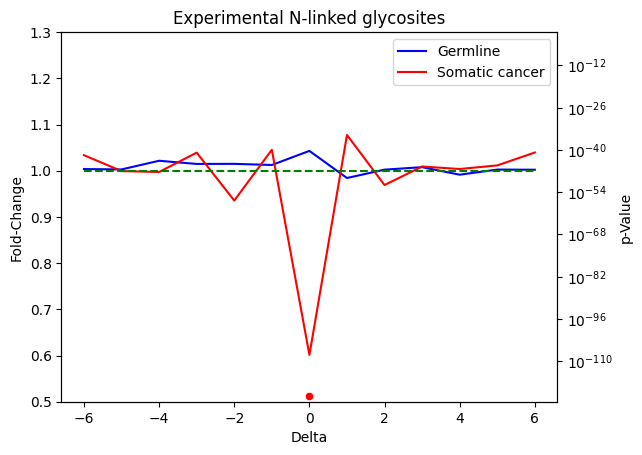

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = delta_counts[delta_counts['delta'].abs()<=6]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax2.set_yscale('log')

colors = {"Germline": "blue", "Somatic cancer": "red"}
sns.lineplot(df,x="delta",y="fc",ax=ax1,hue="variant_type",palette=colors)
df1 = df[df.pvalue<0.001]
sns.scatterplot(df[(df.delta==0)&(df.variant_type=="Somatic cancer")],x="delta",y="pvalue",ax=ax2,
                hue="variant_type",legend=False,palette=colors)
ax1.plot([-6,6],[1,1],'g--')
ax1.set_xlabel("Delta")
ax1.set_ylabel("Fold-Change")
ax2.set_ylabel("p-Value")
ax1.legend(loc='upper right')
ax1.set_ylim([0.5,1.3])
ax2.set_ylim([min(1e-5,min(df.pvalue)/100),1e-1])
ax1.set_title(f"{SITETYPE.title()} {GLYCOTYPE} glycosites")
plt.show()